In [53]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
from flowmap.plot import *

def make_s_curve(n_samples=100, noise=0.0, random_state=None):
    """Generate an S curve dataset.

    Parameters
    ----------
    n_samples : int, default=100
        The number of sample points on the S curve.

    noise : float, default=0.0
        The standard deviation of the gaussian noise.

    random_state : int, Generator instance, or None, default=None
        Determines random number generation for dataset creation. Pass an int
        for reproducible output across multiple function calls.

    Returns
    -------
    X : ndarray of shape (n_samples, 3)
        The points.

    t : ndarray of shape (n_samples,)
        The univariate position of the sample according
        to the main dimension of the points in the manifold.
    """
    # Create a Generator instance
    rng = np.random.default_rng(random_state)

    t = 3 * np.pi * (rng.uniform(size=n_samples) - 0.5)
    X = np.empty(shape=(n_samples, 3), dtype=np.float64)
    X[:, 0] = np.sin(t)
    X[:, 1] = 2.0 * rng.uniform(size=n_samples)
    X[:, 2] = np.sign(t) * (np.cos(t) - 1)
    X += noise * rng.standard_normal(size=(n_samples, 3))
    t = np.squeeze(t)
    return X, t


def compute_s_curve_derivative(t):
    """
    Compute the derivative of the S curve with respect to t.

    Parameters
    ----------
    t : ndarray
        The univariate position of the sample according to the main dimension
        of the points in the manifold.

    Returns
    -------
    dX_dt : ndarray of shape (n_samples, 3)
        The derivatives of the S curve with respect to t for each coordinate.
    """
    # Compute derivatives for each component
    dx0_dt = np.pi * np.cos(t)          # Derivative of sin(t) with respect to t
    dx1_dt = np.zeros_like(t)   # Constant component for y (2.0 * uniform), derivative is zero
    dx2_dt = -np.sin(t) * np.sign(t)  # Derivative of z component with respect to t

    dx0_dy = np.zeros_like(t)    # Constant component for y (2.0 * uniform), derivative is zero
    dx1_dy = 2 * np.ones_like(t)     # Constant component for y (2.0 * uniform), derivative is 1
    dx2_dy = np.zeros_like(t)    # Constant component for y (2.0 * uniform), derivative is zero
    
    # Combine into a single array
    dX_dt = np.stack([dx0_dt, dx1_dt, dx2_dt], axis=1)
    dX_dy = np.stack([dx0_dy, dx1_dy, dx2_dy], axis=1)
    
    return dX_dt, dX_dy


def compute_general_derivative(t, dt_ds):
    """
    Compute the derivative of the S curve with respect to a general parameter s,
    where t is a function of s.

    Parameters
    ----------
    t : ndarray
        The values of t for the S curve.

    dt_ds : ndarray
        The derivative of t with respect to s (dt/ds).

    Returns
    -------
    dX_ds : ndarray of shape (n_samples, 3)
        The derivative of the S curve with respect to s for each coordinate.
    """
    # Compute derivatives for each component with respect to t
    dx0_dt = np.cos(t)          # Derivative of sin(t) with respect to t
    dx1_dt = np.zeros_like(t)   # y-coordinate derivative is zero (constant in this case)
    dx2_dt = -np.sin(t) * np.sign(t)  # Derivative of z-component with respect to t

    # Stack derivatives to form dX/dt
    dX_dt = np.stack([dx0_dt, dx1_dt, dx2_dt], axis=1)

    # Apply chain rule to compute dX/ds
    dX_ds = dX_dt * dt_ds[:, np.newaxis]  # Multiply by dt/ds for each coordinate
    dY_ds = None
    return dX_ds, dY_ds

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


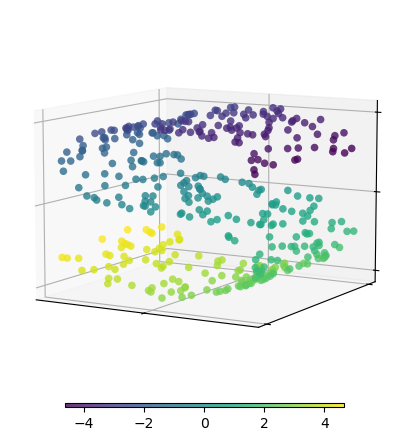

In [54]:
X, t = make_s_curve(400, random_state=42)
fig = plot_3d_scatter(X, t, "", dot_size=30, alpha=0.8)

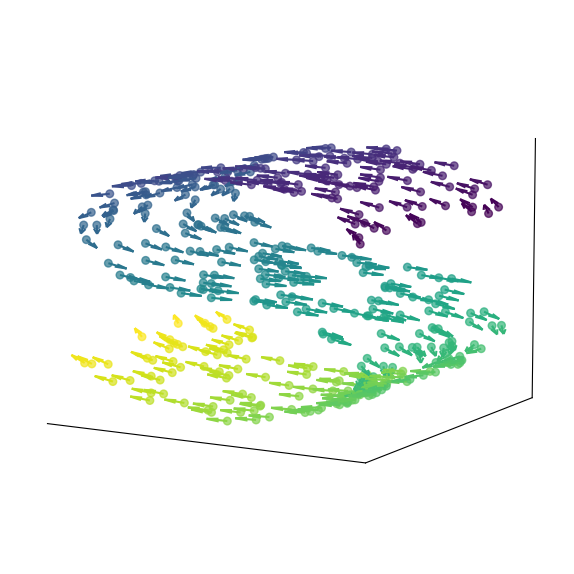

In [55]:
def normalize_rows(dX_dt):
    # Compute the L2 norm for each row (with keepdims for proper broadcasting)
    row_norms = np.linalg.norm(dX_dt, axis=1, keepdims=True)
    
    # Avoid division by zero: if a row's norm is zero, set it to 1 (so the row stays unchanged)
    row_norms[row_norms == 0] = 1
    
    # Divide each element in the row by the corresponding row norm
    return dX_dt / row_norms

# Compute derivatives with respect to s
dX_dt, dX_dy = compute_s_curve_derivative(t)
dX_ds = normalize_rows(dX_dt)
fig = plot_3d_quiver(X, dX_ds, t, s=30, alpha=0.7, 
                    arrow_size=0.15, normalize=False, 
                    title="", cmap="viridis", show_colorbar=False, show_axes=False)

In [56]:
# ------------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------------
rng = np.random.default_rng(42)

# ------------------------------------------------------------------
# Noise levels (position std, velocity std)
# ------------------------------------------------------------------
noise_levels = {
    1:  {"pos": 0.2,  "vel": 0.2},
    2:  {"pos": 0.2,  "vel": 0.4},
    3:  {"pos": 0.2,  "vel": 0.6},
    4:  {"pos": 0.2,  "vel": 0.8},
}

# ------------------------------------------------------------------
# Container for all simulations
# ------------------------------------------------------------------
noisy_simulations = {}

for level, stds in noise_levels.items():
    pos_std = stds["pos"]
    vel_std = stds["vel"]

    noisy_points = X + rng.normal(scale=pos_std, size=X.shape)
    noisy_dX_ds  = dX_ds + rng.normal(scale=vel_std, size=dX_ds.shape)

    noisy_simulations[level] = {
        "X_noisy": noisy_points,
        "V_noisy": noisy_dX_ds,
        "position_noise_std": pos_std,
        "velocity_noise_std": vel_std,
    }

In [57]:
from manfit_velocity import VelocityManifoldFitter

results = {}

for level, data in noisy_simulations.items():
    Xn = data["X_noisy"]
    Vn = data["V_noisy"]

    solver = VelocityManifoldFitter(
        Y=Xn,
        W=Vn,
        k=30,
        d=2,
        alpha=0.2,
        T=15,
        h=1.0,
        theta=0.8,
        use_abs_cos=True,
        recompute_neighbors=False
    )

    X_fit = solver.fit(mode="unweighted")

    results[level] = {
        "X_fit": X_fit,
        "V_fit": solver.v,
        "solver": solver
    }

In [58]:
import matplotlib.pyplot as plt
from matplotlib import cm

def visualize_level(level):
    data = noisy_simulations[level]
    res = results[level]

    Xn = data["X_noisy"]
    Vn = data["V_noisy"]
    Xf = res["X_fit"]
    Vf = res["V_fit"]

    # ---- normalize t for colormap ----
    t_norm = (t - t.min()) / (t.max() - t.min())
    cmap = plt.get_cmap("viridis")

    colors = cmap(t_norm)

    fig = plt.figure(figsize=(12,5))

    # ---- before ----
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.scatter(
        Xn[:,0], Xn[:,1], Xn[:,2],
        s=10, alpha=0.6,
        c=colors
    )
    ax1.quiver(
        Xn[:,0], Xn[:,1], Xn[:,2],
        Vn[:,0], Vn[:,1], Vn[:,2],
        length=0.2,
        normalize=False,
        alpha=0.6,
        colors=colors
    )
    ax1.set_title(f"Before (noise level {level})")

    # ---- after ----
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.scatter(
        Xf[:,0], Xf[:,1], Xf[:,2],
        s=10, alpha=0.8,
        c=colors
    )
    ax2.quiver(
        Xf[:,0], Xf[:,1], Xf[:,2],
        Vf[:,0], Vf[:,1], Vf[:,2],
        length=0.2,
        normalize=False,
        alpha=0.8,
        colors=colors
    )
    ax2.set_title(f"After fitting")

    plt.show()

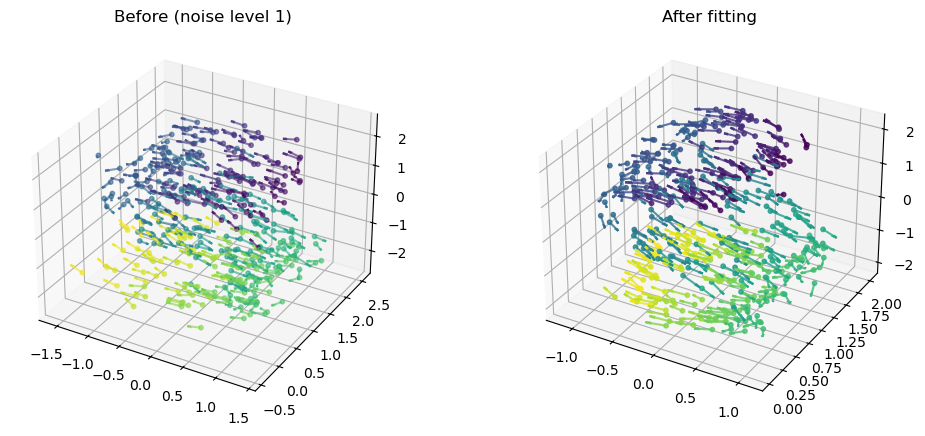

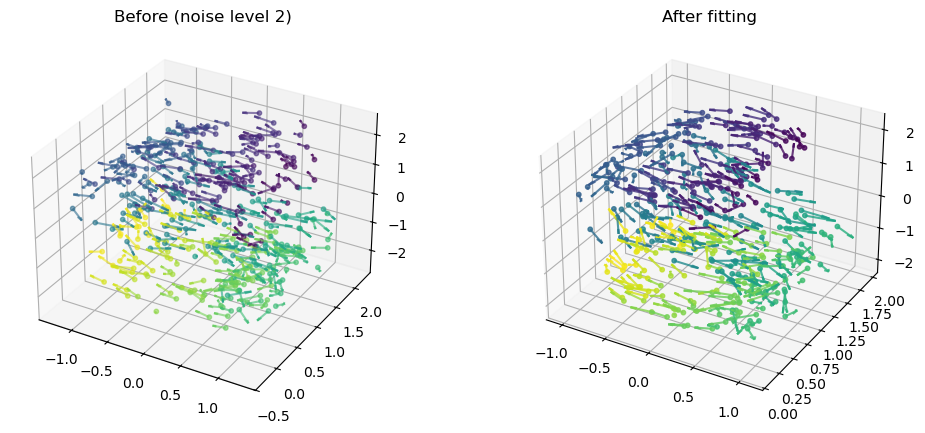

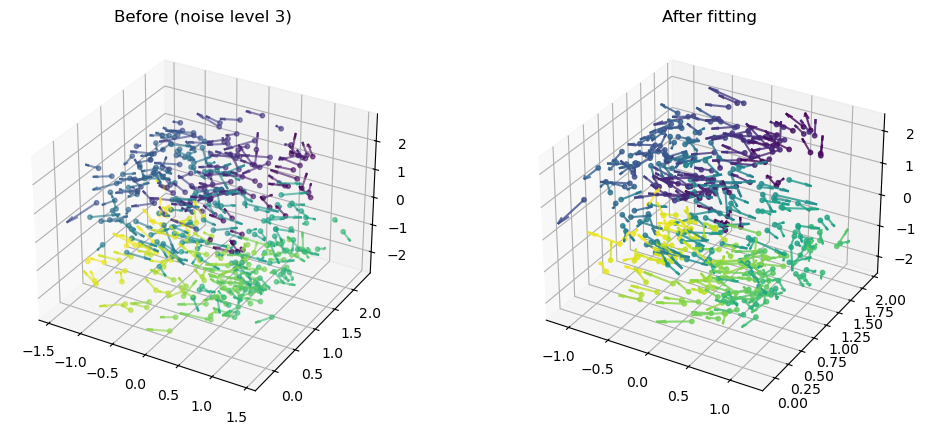

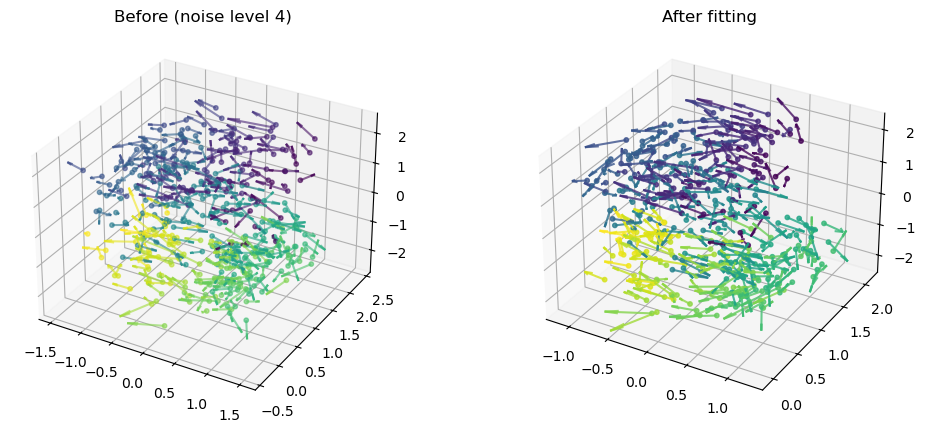

In [59]:
for level in noise_levels:
    visualize_level(level)

In [40]:
import numpy as np
import pandas as pd

def scale_to_unit_box(x, y):
    x_min, x_max = np.min(x), np.max(x)
    y_min, y_max = np.min(y), np.max(y)

    x_range = x_max - x_min
    y_range = y_max - y_min

    if x_range >= y_range:
        scale = 2.0 / x_range  # target: [-1, 1]
        x_scaled = (x - x_min) * scale - 1.0
        y_scaled = (y - y_min) * scale - (y_range / x_range)
    else:
        scale = 2.0 / y_range
        y_scaled = (y - y_min) * scale - 1.0
        x_scaled = (x - x_min) * scale - (x_range / y_range)

    return x_scaled, y_scaled, scale

# ---------- Sampling Function ----------
def sample_points_in_circle(n, r_min=0.0, r_max=1.0, seed=42):
    rng = np.random.default_rng(seed)
    theta = rng.uniform(0, 2 * np.pi, n)
    r = np.sqrt(rng.uniform(r_min**2, r_max**2, n))  # uniform area
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return np.stack([x, y], axis=1)

# ---------- Vector Fields ----------
dataset = {}
n = 1000
np.random.seed(42)

# --- 1. Rotation-only field ---
pos_rot = sample_points_in_circle(n, r_min=0.3, r_max=1.0)
x, y = pos_rot[:, 0], pos_rot[:, 1]
velocity_rot = np.stack([-y, x], axis=1)
theta = np.arctan2(y, x)
time_rot = ((theta + 2 * np.pi) % (2 * np.pi)) / (2 * np.pi)

dataset["rotation"] = {
    "position": pos_rot,
    "velocity": velocity_rot,
    "time": time_rot,
    "name": "rotation"
}

# --- 2. Spiral field ---
pos_spiral = sample_points_in_circle(n, r_min=0.0, r_max=1.0)
x, y = pos_spiral[:, 0], pos_spiral[:, 1]
velocity_spiral = np.stack([x - y, x + y], axis=1)
time_spiral = np.sqrt(x**2 + y**2)
time_spiral /= time_spiral.max()

dataset["spiral"] = {
    "position": pos_spiral,
    "velocity": velocity_spiral,
    "time": time_spiral,
    "name": "spiral"
}

In [41]:
# --- 3. Hyperbolic field ---
# Define the saddle vector field
np.random.seed(42)
n_points = 1000
xlim = ylim = [-2, 2]

X = np.random.uniform(xlim[0], xlim[1], size=(n_points, 2))

# Construct saddle matrix A with eigenvalues -1, +1 along 45°
theta = np.pi / 4
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
Lambda = np.diag([-1, 1])
A = R @ Lambda @ R.T
# Compute vector field
V = X @ A.T

x, y = X[:, 0], X[:, 1]
# Normalize
x, y, scale = scale_to_unit_box(x, y)
X = np.column_stack([x, y])
V = V * scale  # Apply same scale to preserve direction


# Define time
unstable_dir = np.array([1, -1]) / np.sqrt(2)

# Project positions onto unstable direction
proj = X @ unstable_dir

# Use absolute value — origin is time = 0
time_saddle = np.abs(proj)
time_saddle /= time_saddle.max()  # normalize to [0, 1]

# Save to dataset
dataset["saddle"] = {
    "position": X,
    "velocity": V,
    "time": time_saddle,
    "name": "saddle"
}

In [42]:
# --- 4. Quadratic source-sink field ---
def sample_points_in_ball(n, radius=3.0, seed=999):
    rng = np.random.default_rng(seed)
    theta = rng.uniform(0, 2 * np.pi, n)
    r = radius * np.sqrt(rng.uniform(0, 1, n))
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return np.stack([x, y], axis=1)

def quadratic_field(x, y):
    Bx = x**2 - y**2 - 4
    By = 2 * x * y
    return Bx, By

# Sample points
n = 1000
pos_q = sample_points_in_ball(n, radius=3.0)
x, y = pos_q[:, 0], pos_q[:, 1]

# Compute field
Bx, By = quadratic_field(x, y)
velocity_q = np.stack([Bx, By], axis=1)

# Define time: projection onto leftward axis
reference_dir = np.array([-1.0, 0.0])
proj = pos_q @ reference_dir
time_q = (proj - proj.min()) / (proj.max() - proj.min())


x, y, scale = scale_to_unit_box(x, y)
pos_q_scaled = np.column_stack([x, y])
velocity_q_scaled = velocity_q * scale  # scale velocity accordingly

# Recompute time using normalized positions
proj_scaled = pos_q_scaled @ reference_dir
time_q = (proj_scaled - proj_scaled.min()) / (proj_scaled.max() - proj_scaled.min())

# Save to dataset
dataset["quadratic_source_sink"] = {
    "position": pos_q_scaled,
    "velocity": velocity_q_scaled,
    "time": time_q,
    "name": "quadratic_source_sink"
}

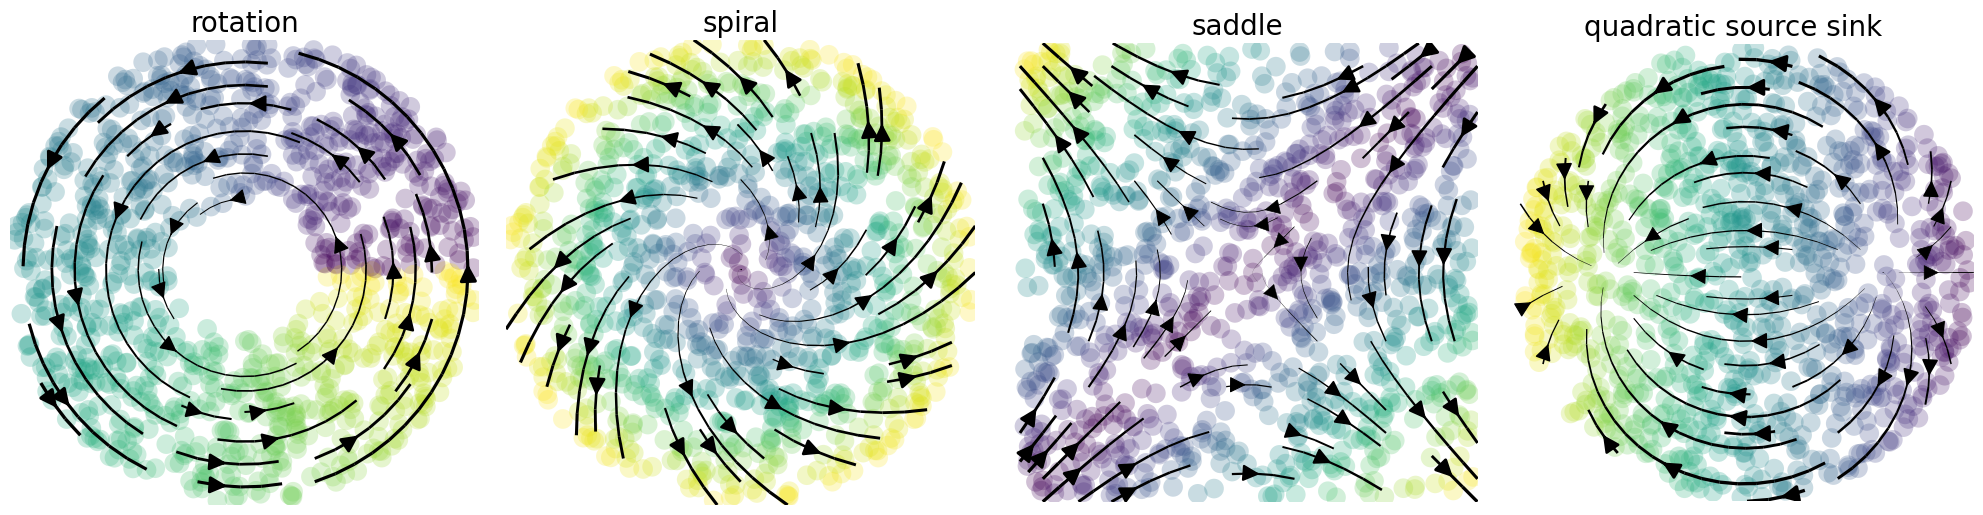

In [43]:
import matplotlib.pyplot as plt
from scripts.TPS import ThinPlateSpline
from scripts.plotting import plot_velocity_streamplot

names = ["rotation", "spiral", "saddle", "quadratic_source_sink"]

fig, axs = plt.subplots(1, 4, figsize=(20, 5))

for ax, name in zip(axs, names):
    data = dataset[name]
    X = data["position"]
    V = data["velocity"]
    time = data["time"]

    # normalize time → [0,1]
    time = (time - time.min()) / (time.max() - time.min() + 1e-12)

    # Fit TPS to smooth vector field (for streamplot)
    tps_vf = ThinPlateSpline(X, n_control_points=100)
    tps_vf.fit(V, dof=15)

    # plot
    plot_velocity_streamplot(
        X_2d=X,
        tps_vf=tps_vf,
        grid_density=1.0,
        stream_density=0.7,
        scatter_color=time,
        scatter_size=200,
        scatter_alpha=0.25,
        ax=ax,
        aspect="equal",
        vmin=0.0,
        vmax=1.0,
        arrowsize=2.5,
        cmap="viridis",
        show_axes=False,
        streamline_thickness=2.5,
        grid_size=50
    )

    ax.set_title(name.replace("_", " "), fontsize=20)

plt.tight_layout()
plt.show()

In [47]:
np.random.seed(42)

simulation_results = {}
noise = 0.3
extra_dim = 5

for name, data in dataset.items():
    X_gt = data["position"]      # (n, 2)
    V_gt = data["velocity"]      # (n, 2)
    time = data["time"]

    # add noise in observed space
    X_noisy = X_gt + np.random.normal(scale=noise, size=X_gt.shape)
    V_noisy = V_gt + np.random.normal(scale=noise, size=V_gt.shape)

    # embed into higher dimension
    X_dummy = np.random.normal(scale=noise, size=(X_gt.shape[0], extra_dim))
    V_dummy = np.random.normal(scale=noise, size=(V_gt.shape[0], extra_dim))

    X = np.hstack([X_noisy, X_dummy])   # (n, 2 + extra_dim)
    V = np.hstack([V_noisy, V_dummy])

    simulation_results[name] = {
        "X": X,
        "V": V,
        "X_gt": X_gt,
        "V_gt": V_gt,
        "true_time": time
    }

In [48]:
from manfit_velocity import VelocityManifoldFitter

fitting_results = {}

for name, data in simulation_results.items():
    X = data["X"]
    V = data["V"]

    solver = VelocityManifoldFitter(
        Y=X,
        W=V,
        k=15,
        d=2,
        alpha=0.5,
        h=1.0,
        T=50,
        theta=0.8,
        use_abs_cos=True,
        recompute_neighbors=False
    )

    X_fit = solver.fit(eta=0.2, mode="unweighted")

    fitting_results[name] = {
        "X_fit": X_fit,
        "V_fit": solver.v
    }

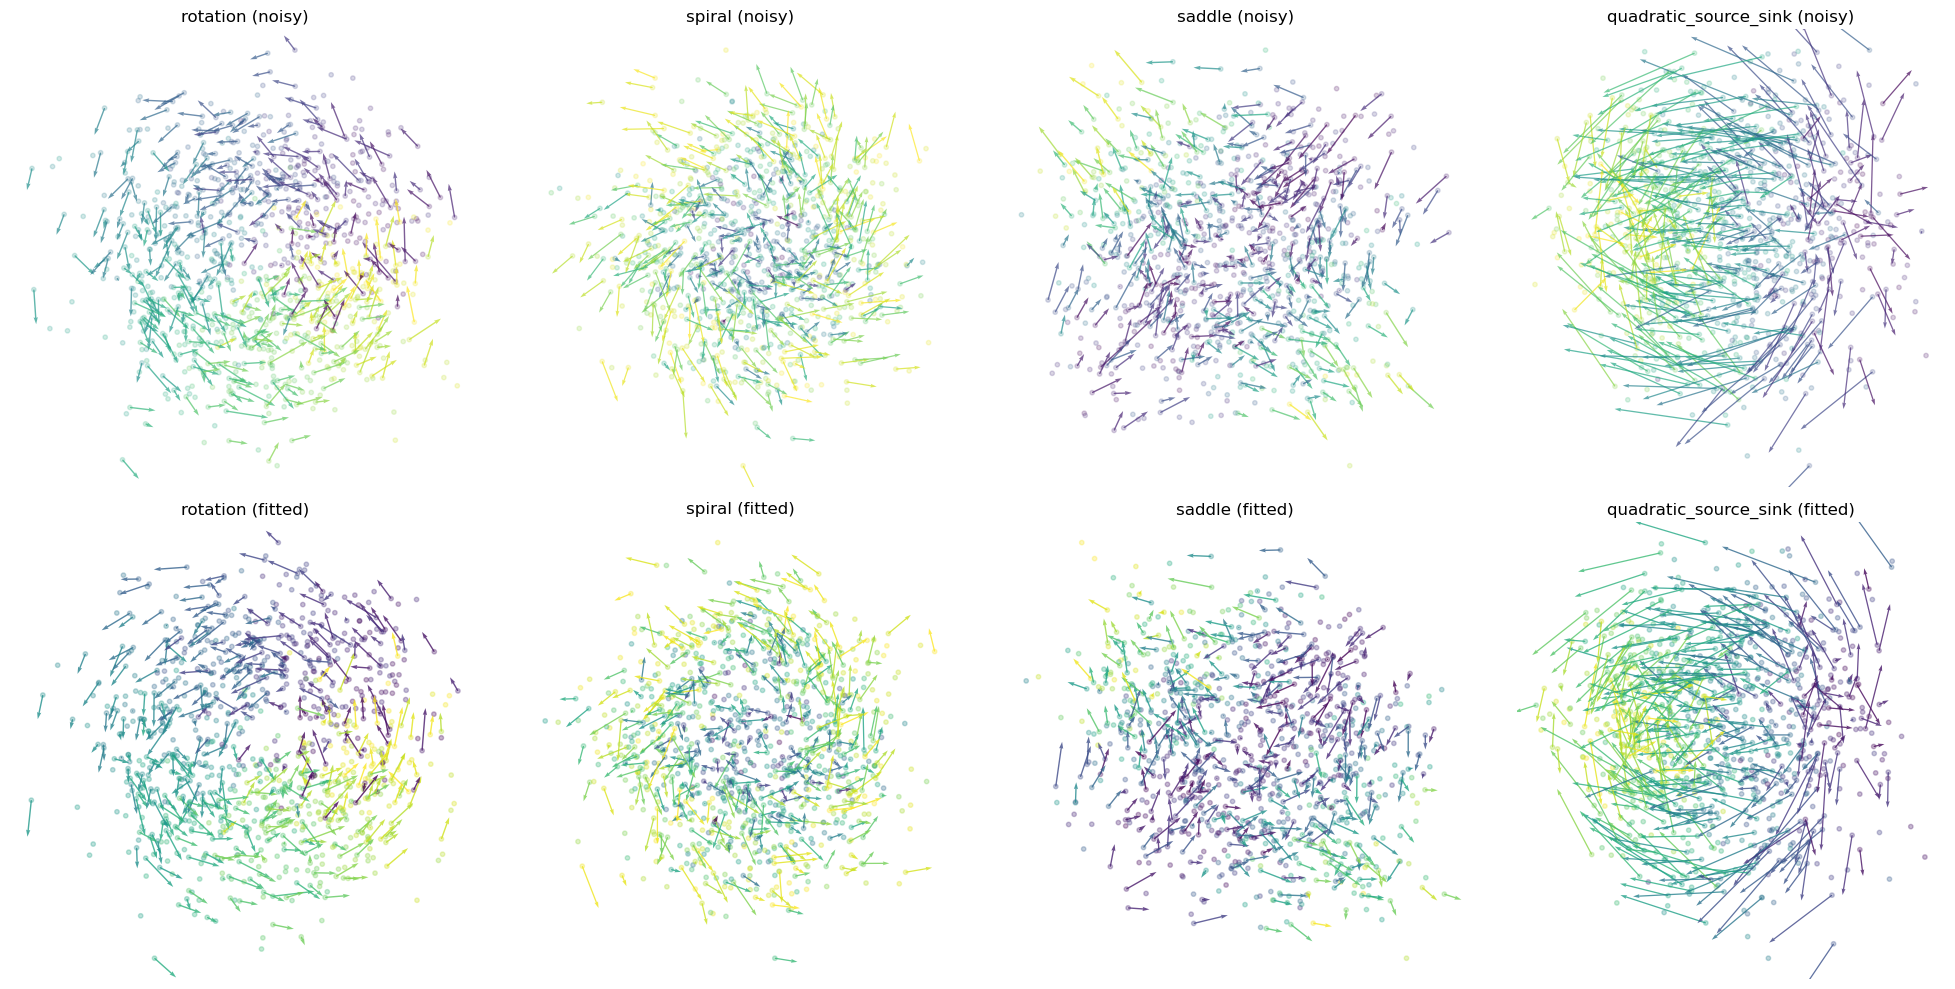

In [49]:
import matplotlib.pyplot as plt
import numpy as np

names = ["rotation", "spiral", "saddle", "quadratic_source_sink"]

fig, axs = plt.subplots(2, 4, figsize=(20, 10))

for i, name in enumerate(names):
    data = simulation_results[name]
    fit = fitting_results[name]

    # ---- noisy (project to 2D) ----
    X_noisy = data["X"][:, :2]
    V_noisy = data["V"][:, :2]

    # ---- fitted ----
    X_fit = fit["X_fit"][:, :2]
    V_fit = fit["V_fit"][:, :2]

    # ---- color (time) ----
    time = data["true_time"]
    time = (time - time.min()) / (time.max() - time.min() + 1e-12)

    # subsample for readability (VERY important)
    idx = np.random.choice(len(X_noisy), size=400, replace=False)

    # ---- TOP: noisy ----
    ax = axs[0, i]
    ax.scatter(X_noisy[:, 0], X_noisy[:, 1],
               c=time, cmap="viridis", s=10, alpha=0.2)

    ax.quiver(
        X_noisy[idx, 0], X_noisy[idx, 1],
        V_noisy[idx, 0], V_noisy[idx, 1],
        color=plt.cm.viridis(time[idx]),
        angles='xy',
        scale_units='xy',
        scale=5,
        alpha=0.7,
        width=0.003
    )

    ax.set_title(f"{name} (noisy)")
    ax.set_aspect("equal")
    ax.axis("off")

    # ---- BOTTOM: fitted ----
    ax = axs[1, i]
    ax.scatter(X_fit[:, 0], X_fit[:, 1],
               c=time, cmap="viridis", s=10, alpha=0.3)

    ax.quiver(
        X_fit[idx, 0], X_fit[idx, 1],
        V_fit[idx, 0], V_fit[idx, 1],
        color=plt.cm.viridis(time[idx]),
        angles='xy',
        scale_units='xy',
        scale=5,
        alpha=0.8,
        width=0.003
    )

    ax.set_title(f"{name} (fitted)")
    ax.set_aspect("equal")
    ax.axis("off")

plt.tight_layout()
plt.show()